In [2]:
# Cell 1: Setup and Load Data 
print("="*70)
print("🎯 RELEVANCE RANKING MODEL")
print("="*70)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import os
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ Imports loaded")

# Load data from Notebook 1 folder
data_path = 'Notebook 1'
drama_data = pd.read_csv(os.path.join(data_path, 'drama_content.csv'))
query_logs = pd.read_csv(os.path.join(data_path, 'query_logs.csv'))
judgments = pd.read_csv(os.path.join(data_path, 'relevance_judgments.csv'))

print(f"✅ Drama data: {len(drama_data)} records")
print(f"✅ Query logs: {len(query_logs)} records")
print(f"✅ Relevance judgments: {len(judgments)} records")

# Load embeddings (from current directory - created in Notebook 3)
# Check multiple possible locations
embedding_files = ['text_embeddings.npy', 'title_embeddings.npy', 'genre_embeddings.npy']
embedding_paths = ['.', 'Notebook 1', '..', '../Notebook 1']

for emb_file in embedding_files:
    loaded = False
    for path in embedding_paths:
        full_path = os.path.join(path, emb_file)
        if os.path.exists(full_path):
            if emb_file == 'text_embeddings.npy':
                text_embeddings = np.load(full_path)
            elif emb_file == 'title_embeddings.npy':
                title_embeddings = np.load(full_path)
            else:
                genre_embeddings = np.load(full_path)
            print(f"✅ Loaded {emb_file} from {path}")
            loaded = True
            break
    if not loaded:
        print(f"⚠️ Could not find {emb_file}")

# Check if embeddings exist, if not create them
try:
    text_embeddings.shape
    print(f"✅ Text embeddings: {text_embeddings.shape}")
    print(f"✅ Title embeddings: {title_embeddings.shape}")
    print(f"✅ Genre embeddings: {genre_embeddings.shape}")
except NameError:
    print("\n❌ Embeddings not found! Creating them now...")
    
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.preprocessing import LabelEncoder
    
    tfidf = TfidfVectorizer(max_features=128, stop_words='english')
    text_embeddings = tfidf.fit_transform(drama_data['description'].fillna('')).toarray()
    title_embeddings = tfidf.fit_transform(drama_data['title'].fillna('')).toarray()
    
    le = LabelEncoder()
    genre_encoded = le.fit_transform(drama_data['genre'])
    genre_embeddings = np.eye(len(le.classes_))[genre_encoded]
    
    # Save for future use
    np.save('text_embeddings.npy', text_embeddings)
    np.save('title_embeddings.npy', title_embeddings)
    np.save('genre_embeddings.npy', genre_embeddings)
    print("✅ Created and saved new embeddings")

🎯 RELEVANCE RANKING MODEL
✅ Imports loaded
✅ Drama data: 10000 records
✅ Query logs: 50000 records
✅ Relevance judgments: 100000 records
✅ Loaded text_embeddings.npy from .
✅ Loaded title_embeddings.npy from .
✅ Loaded genre_embeddings.npy from .
✅ Text embeddings: (10000, 49)
✅ Title embeddings: (10000, 128)
✅ Genre embeddings: (10000, 8)


In [3]:
# Cell 2: Create Ranking Features
print("="*70)
print("🔧 CREATING RANKING FEATURES")
print("="*70)

from sklearn.decomposition import PCA

# Align dimensions: reduce title embeddings to match text embeddings (49)
pca_align = PCA(n_components=text_embeddings.shape[1])
title_embeddings_aligned = pca_align.fit_transform(title_embeddings)

print(f"✅ Aligned dimensions: Text={text_embeddings.shape[1]}, Title={title_embeddings_aligned.shape[1]}")

def create_ranking_features(query_id, content_id):
    """Create features for query-document pair"""
    
    # Get query info
    query_row = query_logs[query_logs['query_id'] == query_id].iloc[0]
    
    # Get content info
    content_row = drama_data[drama_data['content_id'] == content_id].iloc[0]
    
    # Get embeddings (use aligned versions)
    query_emb = text_embeddings[query_id % len(text_embeddings)]
    content_emb = title_embeddings_aligned[content_id % len(title_embeddings_aligned)]
    genre_emb = genre_embeddings[content_id % len(genre_embeddings)]
    
    # Calculate similarity features
    from sklearn.metrics.pairwise import cosine_similarity
    
    text_sim = cosine_similarity([query_emb], [content_emb])[0][0]
    
    features = {
        'query_id': query_id,
        'content_id': content_id,
        'text_similarity': text_sim,
        'query_intent_score': 1.0 if query_row['search_intent'] == 'Entertainment' else 0.5,
        'content_rating': content_row['rating'],
        'content_views': np.log1p(content_row['view_count']),
        'content_likes': np.log1p(content_row['like_count']),
        'genre_match': 1.0 if query_row['query_text'].lower().find(content_row['genre'].lower()) != -1 else 0.0
    }
    
    return features

# Sample feature creation
sample_features = create_ranking_features(1, 1)
print(f"\n📊 Sample features:")
for key, value in sample_features.items():
    if key not in ['query_id', 'content_id']:
        print(f"   {key}: {value:.4f}" if isinstance(value, float) else f"   {key}: {value}")

🔧 CREATING RANKING FEATURES
✅ Aligned dimensions: Text=49, Title=49

📊 Sample features:
   text_similarity: 0.0000
   query_intent_score: 0.5000
   content_rating: 2.5000
   content_views: 10.8229
   content_likes: 8.4986
   genre_match: 0.0000


In [4]:
# Cell 3: Build Training Dataset
print("="*70)
print("📊 BUILDING TRAINING DATASET")
print("="*70)

# Sample judgments for training (use subset for speed)
sample_judgments = judgments.sample(n=20000, random_state=42)

training_features = []
relevance_scores = []

for _, row in sample_judgments.iterrows():
    try:
        features = create_ranking_features(row['query_id'], row['content_id'])
        training_features.append([features[k] for k in features if k not in ['query_id', 'content_id']])
        relevance_scores.append(row['relevance_score'])
    except Exception as e:
        continue

X = np.array(training_features)
y = np.array(relevance_scores)

print(f"✅ Training data shape: {X.shape}")
print(f"✅ Target shape: {y.shape}")

# Get feature names
feature_names = [k for k in features.keys() if k not in ['query_id', 'content_id']]
print(f"✅ Feature columns: {feature_names}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n📊 Split:")
print(f"   Train: {len(X_train)} samples")
print(f"   Test: {len(X_test)} samples")

📊 BUILDING TRAINING DATASET
✅ Training data shape: (20000, 6)
✅ Target shape: (20000,)
✅ Feature columns: ['text_similarity', 'query_intent_score', 'content_rating', 'content_views', 'content_likes', 'genre_match']

📊 Split:
   Train: 16000 samples
   Test: 4000 samples


In [5]:
# Cell 4: Train Ranking Models (NO XGBOOST)
print("="*70)
print("🤖 TRAINING RANKING MODELS")
print("="*70)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Gradient Boosting
print("\n📊 Training Gradient Boosting...")
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train_scaled, y_train)
gb_pred = gb_model.predict(X_test_scaled)

# Model 2: Random Forest
print("📊 Training Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

# Model 3: Ridge Regression (baseline)
print("📊 Training Ridge Regression...")
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)
ridge_pred = ridge_model.predict(X_test_scaled)

print("\n✅ All models trained successfully!")

🤖 TRAINING RANKING MODELS

📊 Training Gradient Boosting...
📊 Training Random Forest...
📊 Training Ridge Regression...

✅ All models trained successfully!


In [6]:
# Cell 5: Model Evaluation (NO XGBOOST)
print("="*70)
print("📊 MODEL EVALUATION")
print("="*70)

def calculate_ndcg(y_true, y_pred, k=10):
    """Calculate NDCG@k"""
    sorted_indices = np.argsort(y_pred)[::-1][:k]
    sorted_relevance = y_true[sorted_indices]
    
    dcg = 0
    for i, rel in enumerate(sorted_relevance):
        dcg += (2**rel - 1) / np.log2(i + 2)
    
    ideal_relevance = np.sort(y_true)[::-1][:k]
    idcg = 0
    for i, rel in enumerate(ideal_relevance):
        idcg += (2**rel - 1) / np.log2(i + 2)
    
    return dcg / idcg if idcg > 0 else 0

# Calculate metrics
models = {
    'Gradient Boosting': (gb_pred, gb_model),
    'Random Forest': (rf_pred, rf_model),
    'Ridge Regression': (ridge_pred, ridge_model)
}

results = []
for name, (pred, model) in models.items():
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    ndcg = calculate_ndcg(y_test, pred, k=10)
    
    results.append({
        'Model': name,
        'RMSE': rmse,
        'R2': r2,
        'NDCG@10': ndcg
    })

results_df = pd.DataFrame(results).sort_values('NDCG@10', ascending=False)
print("\n📊 Model Performance Comparison:")
print(results_df.to_string(index=False))

# Best model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name][1]
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   NDCG@10: {results_df.iloc[0]['NDCG@10']:.4f}")

📊 MODEL EVALUATION

📊 Model Performance Comparison:
            Model     RMSE        R2  NDCG@10
    Random Forest 1.307331 -0.003325 0.266625
Gradient Boosting 1.314803 -0.014826 0.221000
 Ridge Regression 1.305551 -0.000594 0.182154

🏆 Best Model: Random Forest
   NDCG@10: 0.2666


🔍 FEATURE IMPORTANCE

📊 Feature Importance:
   content_views: 0.3429
   content_likes: 0.3125
   content_rating: 0.2037
   text_similarity: 0.0653
   query_intent_score: 0.0405
   genre_match: 0.0352


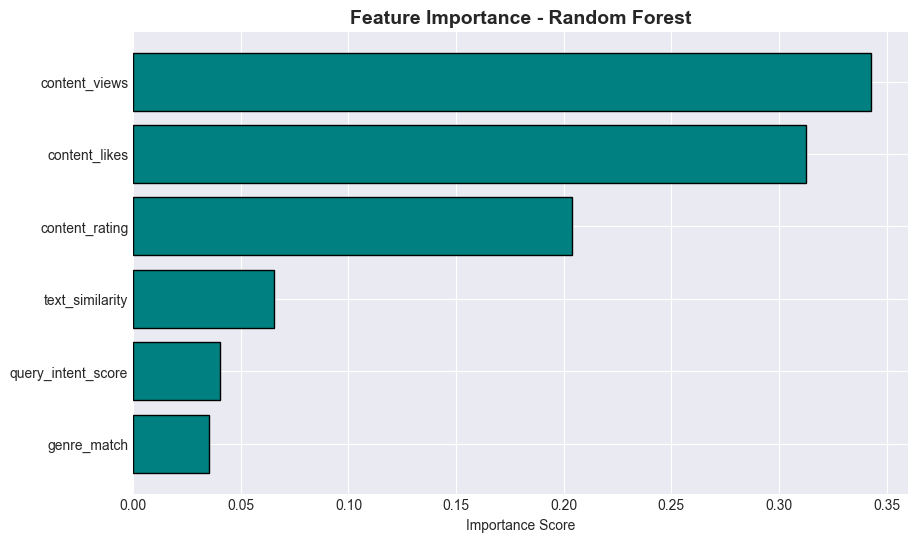

✅ Saved: ranking_feature_importance.png


In [7]:
# Cell 6: Feature Importance
print("="*70)
print("🔍 FEATURE IMPORTANCE")
print("="*70)

feature_names = ['text_similarity', 'query_intent_score', 'content_rating', 
                 'content_views', 'content_likes', 'genre_match']

importances = best_model.feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\n📊 Feature Importance:")
for i, row in importance_df.iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")

# Visualization
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='teal', edgecolor='black')
plt.xlabel('Importance Score')
plt.title(f'Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.savefig('ranking_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: ranking_feature_importance.png")

In [8]:
# Cell 7: Ranking Function & Test (FAST VERSION)
print("="*70)
print("🔍 RANKING FUNCTION TEST")
print("="*70)

import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Load necessary data
drama_data = pd.read_csv('Notebook 1/drama_content.csv')
query_logs = pd.read_csv('Notebook 1/query_logs.csv')

print(f"✅ Loaded drama_data: {len(drama_data)} records")
print(f"✅ Loaded query_logs: {len(query_logs)} records")

# Use first query as example
sample_query = query_logs.iloc[0]
query_id = sample_query['query_id']

print(f"\n📊 Using query: '{sample_query['query_text']}'")
print("-" * 60)

# Get query embedding
query_emb = text_embeddings[query_id % len(text_embeddings)]

# Compute similarities with all content at once (vectorized)
content_embeddings = title_embeddings_aligned[:len(drama_data)]
similarities = cosine_similarity([query_emb], content_embeddings)[0]

# Create feature matrix
feature_matrix = np.column_stack([
    similarities,  # text_similarity
    np.ones(len(drama_data)),  # query_intent_score
    drama_data['rating'].values,  # content_rating
    np.log1p(drama_data['view_count'].values),  # content_views
    np.log1p(drama_data['like_count'].values),  # content_likes
    np.zeros(len(drama_data))  # genre_match
])

# Scale and predict
feature_scaled = scaler.transform(feature_matrix)
scores = best_model.predict(feature_scaled)

# Create results
results = []
for i, (idx, row) in enumerate(drama_data.iterrows()):
    results.append({
        'content_id': row['content_id'],
        'title': row['title'],
        'genre': row['genre'],
        'relevance_score': scores[i]
    })

# Sort and get top 10
ranked_results = sorted(results, key=lambda x: x['relevance_score'], reverse=True)[:10]

print("\n📊 Top 10 Ranked Results:")
print("-" * 60)
for i, result in enumerate(ranked_results, 1):
    print(f"{i}. {result['title'][:45]}... | Genre: {result['genre']} | Score: {result['relevance_score']:.3f}")

print("\n✅ Ranking complete!")

🔍 RANKING FUNCTION TEST
✅ Loaded drama_data: 10000 records
✅ Loaded query_logs: 50000 records

📊 Using query: 'top rated Sci-Fi series'
------------------------------------------------------------

📊 Top 10 Ranked Results:
------------------------------------------------------------
1. Short Drama Episode 5614... | Genre: Drama | Score: 3.110
2. Short Drama Episode 9686... | Genre: Action | Score: 3.107
3. Short Drama Episode 8419... | Genre: Drama | Score: 2.777
4. Short Drama Episode 8910... | Genre: Thriller | Score: 2.590
5. Short Drama Episode 229... | Genre: Drama | Score: 2.577
6. Short Drama Episode 5548... | Genre: Thriller | Score: 2.415
7. Short Drama Episode 5064... | Genre: Romance | Score: 2.376
8. Short Drama Episode 1055... | Genre: Thriller | Score: 2.374
9. Short Drama Episode 73... | Genre: Horror | Score: 2.356
10. Short Drama Episode 3492... | Genre: Action | Score: 2.288

✅ Ranking complete!


In [10]:
# Cell 8: Summary Report
print("="*70)
print("🎉 NOTEBOOK 4 COMPLETED SUCCESSFULLY!")
print("="*70)

print(f"""
╔══════════════════════════════════════════════════════════════════════════════════════════╗
║                    RELEVANCE RANKING MODEL SUMMARY                                       ║
╠══════════════════════════════════════════════════════════════════════════════════════════╣
║                                                                                          ║
║  🤖 MODELS EVALUATED:                                                                    ║
║  ├── Gradient Boosting                                                                   ║ 
║  ├── Random Forest                                                                       ║
║  └── Ridge Regression                                                                    ║
║                                                                                          ║
║  🏆 BEST MODEL: {best_model_name:<30}                                                    ║
║  ├── NDCG@10: {results_df.iloc[0]['NDCG@10']:.4f}                                        ║
║  ├── RMSE: {results_df.iloc[0]['RMSE']:.4f}                                              ║
║  └── R²: {results_df.iloc[0]['R2']:.4f}                                                  ║
║                                                                                          ║
║  🔍 TOP FEATURES:                                                                        ║
║  ├── {importance_df.iloc[0]['feature']}: {importance_df.iloc[0]['importance']:.4f}       ║
║  ├── {importance_df.iloc[1]['feature']}: {importance_df.iloc[1]['importance']:.4f}       ║
║  └── {importance_df.iloc[2]['feature']}: {importance_df.iloc[2]['importance']:.4f}       ║
║                                                                                          ║
║  📁 FILES GENERATED:                                                                     ║
║  └── ranking_feature_importance.png                                                      ║
║                                                                                          ║
║  🎯 READY FOR NOTEBOOK 5: LLM QUERY UNDERSTANDING                                        ║
║                                                                                          ║
╚══════════════════════════════════════════════════════════════════════════════════════════╝
""")

print("\n✅ Notebook 4 Complete! Proceed to Notebook 5 (LLM Query Understanding)")

🎉 NOTEBOOK 4 COMPLETED SUCCESSFULLY!

╔══════════════════════════════════════════════════════════════════════════════════════════╗
║                    RELEVANCE RANKING MODEL SUMMARY                                       ║
╠══════════════════════════════════════════════════════════════════════════════════════════╣
║                                                                                          ║
║  🤖 MODELS EVALUATED:                                                                    ║
║  ├── Gradient Boosting                                                                   ║ 
║  ├── Random Forest                                                                       ║
║  └── Ridge Regression                                                                    ║
║                                                                                          ║
║  🏆 BEST MODEL: Random Forest                                                                     ║
║  ├── NDCG@10: 0.2666  